# **MÓDULO 13**
# Projeto - Fundamentos da Descoberta de Dados

Nesse projeto trabalharemos com a base de dados de produtos de um supermercado do Chile.
A ideia é que vocês apliquem os conceitos estatísticos vistos no último módulo, mais os conceitos de visualizações de dados através de gráficos e finalizem publicando no seu github!

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px

In [1]:
import pandas as pd

df = pd.read_csv(
    r"C:\Users\ELIAS\Downloads\MODULO7_PROJETOFINAL_BASE_SUPERMERCADO - MODULO7_PROJETOFINAL_BASE_SUPERMERCADO (1).csv.csv"
)

df.head(10)

,title,Marca,Preco_Normal,Preco_Desconto,Preco_Anterior,Desconto,Categoria
0,"Pack 12 un, Leche extra proteína 1 L",Loncoleche,19788,0,0,0,lacteos
1,"Pack 12 un, Leche chocolate receta original 1 L",Soprole,18228,0,0,0,lacteos
2,"Pack 12 un, Leche semidescremada chocolate 1 L",Soprole,18228,0,0,0,lacteos
3,"Pack 12 un, Leche semidescremada frutilla 1 L",Soprole,18228,0,0,0,lacteos
4,"Pack 12 un, Leche sin lactosa chocolate 1 L",Loncoleche,17988,0,0,0,lacteos
5,"Pack 12 un, Leche sin lactosa frutilla 1 L",Loncoleche,17988,0,0,0,lacteos
6,"Pack 12 un, Leche saborizada light chocolate 1 L",Loncoleche,17988,0,0,0,lacteos
7,"Pack 12 un, Leche saborizada frutilla 1 L",Colun,17388,0,0,0,lacteos
8,"Pack 12 un, Leche saborizada vainilla 1 L",Colun,17388,0,0,0,lacteos
9,"Pack 12 un, Leche saborizada manjar 1 L",Colun,17388,0,0,0,lacteos


Os campos do nosso dataframe são:

**Title:** Nome do produto.


**Marca:** A marca do produto.


**Preco_Normal:** O preço em que o produto costuma ser vendido quando não há desconto.


**Preco_Desconto:** O preço vendido após o desconto ser aplicado.


**Preco_Anterior:** Preço em que era comercializado o produto antes do desconto aplicado.


**Desconto:** Total de desconto aplicado.






As colunas que aparecem com valores 0 são para os produtos onde não tivemos descontos aplicados.


As categorias estão em espanhol!

# 1 - Traga a média e a mediana dos preços - coluna Preco_Normal - por categoria de produto.
# Identifique as categorias que parecem ter um valor de média abaixo ou acima da mediana.

In [5]:
media_categoria = df.groupby('Categoria')['Preco_Normal'].mean()
print(media_categoria)


Categoria
belleza-y-cuidado-personal    1783.556485
comidas-preparadas            3095.043478
congelados                    2108.042553
frutas                        1724.473684
instantaneos-y-sopas           765.491228
lacteos                       2385.219239
verduras                      1343.296875
Name: Preco_Normal, dtype: float64


In [6]:
mediana_categoria = df.groupby('Categoria')['Preco_Normal'].median()
print(mediana_categoria)


Categoria
belleza-y-cuidado-personal    1569.0
comidas-preparadas            3290.0
congelados                    1519.0
frutas                        1195.0
instantaneos-y-sopas           439.0
lacteos                        989.0
verduras                      1180.0
Name: Preco_Normal, dtype: float64


As categorias que apresentam a média muito acima da mediana possuem produtos com valores extremamente altos puxando a média para cima.

As principais categorias com esse comportamento são:

lacteos
congelados
frutas
instantaneos-y-sopas
belleza-y-cuidado-personal

Isso indica presença de valores discrepantes (outliers).

Já a categoria: comidas-preparadas
apresenta média próxima da mediana, indicando distribuição mais equilibrada.

# 2 - Traga o desvio padrão por categoria de produto.
# Qual o comportamento da média e mediana nas categorias com maior desvio?

In [7]:
desvio = df.groupby('Categoria')['Preco_Normal'].std()
print(desvio)


Categoria
belleza-y-cuidado-personal    2210.041719
comidas-preparadas            2019.911428
congelados                    2111.539896
frutas                        1639.151114
instantaneos-y-sopas          1170.232869
lacteos                       3925.816164
verduras                      1012.699625
Name: Preco_Normal, dtype: float64


A categoria com maior desvio padrão foi:

lacteos

Isso mostra que os preços dessa categoria possuem grande variação.

Quando o desvio padrão é muito alto:

a média tende a ficar distante da mediana;
existem produtos muito acima do valor comum da categoria;
os dados ficam mais dispersos.

Isso confirma a presença de outliers.

# 3 - Plot um boxplot da distribuição do Preco_Normal para a categoria que você identificou que tem o maior desvio padrão. Como é a distribuição desses dados segundo o boxplot? Você identifica muitos outliers?

Dica: Para trazer apenas os dados da categoria que você deseja você pode usar o df.loc[df['Categoria'] == 'CATEGORIA ESCOLHIDA'

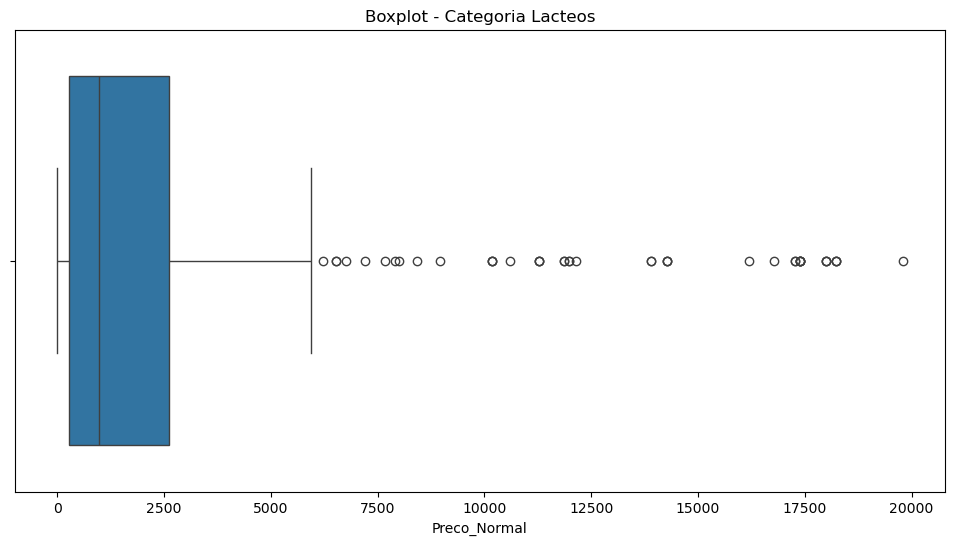

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

lacteos = df.loc[df['Categoria'] == 'lacteos']

plt.figure(figsize=(12,6))
sns.boxplot(x=lacteos['Preco_Normal'])
plt.title('Boxplot - Categoria Lacteos')
plt.show()


# 4 - Plote um gráfico de barras onde temos a média de descontos por categoria.

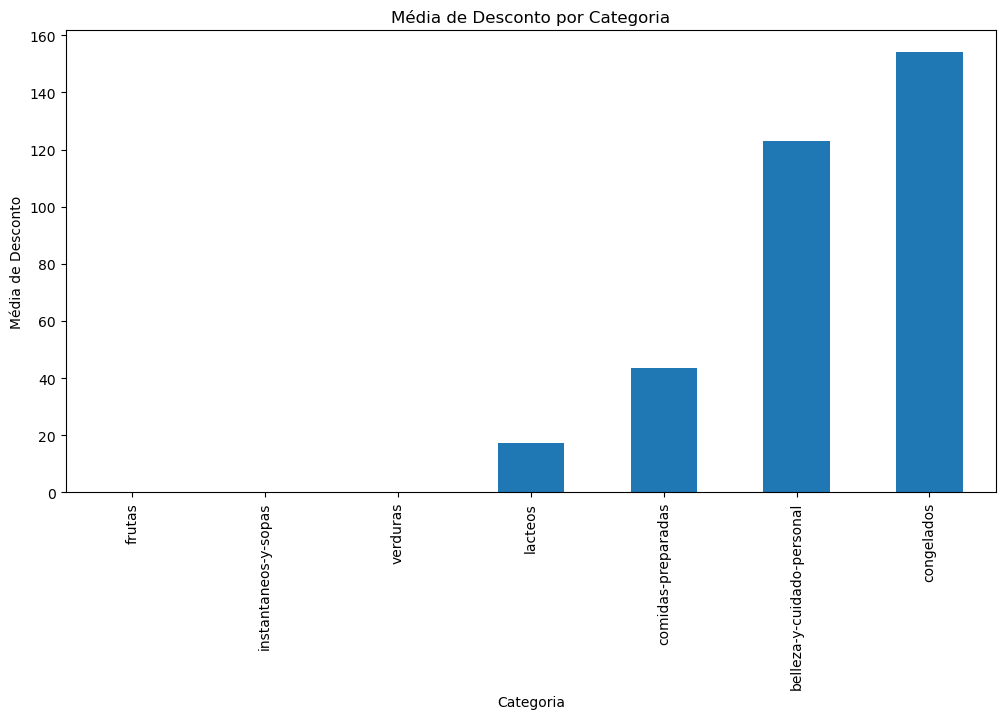

In [14]:
media_desconto = df.groupby('Categoria')['Desconto'].mean().sort_values()

plt.figure(figsize=(12,6))
media_desconto.plot(kind='bar')
plt.title('Média de Desconto por Categoria')
plt.xlabel('Categoria')
plt.ylabel('Média de Desconto')
plt.show()


# 5 - Plote um gráfico de mapa interativo agrupando os dados por categoria, marca e trazendo a média de desconto.

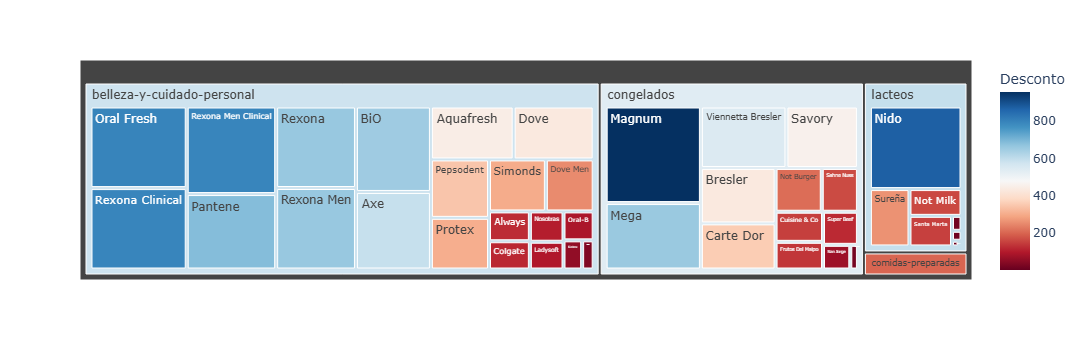

In [13]:
import plotly.express as px

mapa = df.groupby(['Categoria', 'Marca'])['Desconto'].mean().reset_index()

fig = px.treemap(
    mapa,
    path=['Categoria', 'Marca'],
    values='Desconto',
    color='Desconto',
    color_continuous_scale='RdBu'
)

fig.show()
